## 1. Data cleaning and pre-processing

In [1]:
import pandas as pd

ferryterminal_el_demand = pd.read_excel("inputs/ferryterminal_el_demand.xlsx")

In [2]:
# Take first two columns, exclude first data row after header,
# rename columns, and parse datetime
ferryterminal_el_demand = (
    ferryterminal_el_demand.iloc[1:, [0, 1]]
      .copy()
      .rename(columns={ferryterminal_el_demand.columns[0]: "datetime", ferryterminal_el_demand.columns[1]: "ampere"})
)
ferryterminal_el_demand["datetime"] = pd.to_datetime(
    ferryterminal_el_demand["datetime"], errors="coerce"
)
ferryterminal_el_demand["ampere"] = pd.to_numeric(
    ferryterminal_el_demand["ampere"], errors="coerce"
)

In [3]:
ferryterminal_el_demand.head()

,datetime,ampere
1,2025-03-01 00:15:00,3.533
2,2025-03-01 00:30:00,3.567
3,2025-03-01 00:45:00,3.582
4,2025-03-01 01:00:00,3.692
5,2025-03-01 01:15:00,3.704


In [4]:
ferryterminal_el_demand.tail()

,datetime,ampere
35035,2026-02-28 22:45:00,2.605
35036,2026-02-28 23:00:00,2.567
35037,2026-02-28 23:15:00,2.594
35038,2026-02-28 23:30:00,2.658
35039,2026-02-28 23:45:00,2.542


Since the given dataset is from March 2025 to February 2026, the January and February 2026 data is taken and shifted at the beginning of the dataset as it was 2025.

In [5]:
# Build a Jan-Dec 2025 series by moving Jan/Feb 2026 to Jan/Feb 2025
df_months_shift = ferryterminal_el_demand.copy()

mask_jan_feb_2026 = (
    (df_months_shift["datetime"].dt.year == 2026) &
    (df_months_shift["datetime"].dt.month.isin([1, 2]))
)

# Jan/Feb 2026 -> Jan/Feb 2025
part_jf_2025 = df_months_shift.loc[mask_jan_feb_2026].copy()
part_jf_2025["datetime"] = part_jf_2025["datetime"] - pd.DateOffset(years=1)

# Keep Mar-Dec 2025
part_mar_dec_2025 = df_months_shift.loc[
    (df_months_shift["datetime"].dt.year == 2025) &
    (df_months_shift["datetime"].dt.month >= 3)
].copy()

# Final dataset: Jan 2025 ... Dec 2025
ferryterminal_el_demand = (
    pd.concat([part_jf_2025, part_mar_dec_2025], ignore_index=True)
      .sort_values("datetime")
      .reset_index(drop=True)
)

# Optional quick checks
print(ferryterminal_el_demand["datetime"].min())
print(ferryterminal_el_demand["datetime"].max())
print(ferryterminal_el_demand["datetime"].dt.year.value_counts())

2025-01-01 00:00:00
2025-12-31 23:45:00
datetime
2025    35039
Name: count, dtype: int64


Converting to kWh for visualization

In [6]:
ferryterminal_el_demand_hourly = (
    ferryterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .resample("h")["ampere"]
    .sum()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(0.25) # convert to kWh
    .reset_index()
    .rename(columns={"ampere": "energy_kWh"})
)

ferryterminal_el_demand_hourly.head()

,datetime,energy_kWh
0,2025-01-01 00:00:00,34.373375
1,2025-01-01 01:00:00,33.753500
2,2025-01-01 02:00:00,33.938750
3,2025-01-01 03:00:00,33.822375
4,2025-01-01 04:00:00,32.760750


In [7]:
# Copy and normalize datetime
ft = ferryterminal_el_demand_hourly.copy()
ft["datetime"] = pd.to_datetime(ft["datetime"], errors="coerce")
ft = ft.dropna(subset=["datetime"]).sort_values("datetime")

# Pick power column (adjust if your column name differs)
power_col = "energy_kWh"  # e.g. "demand_kW" if that is your actual column

# Ensure numeric
ft[power_col] = pd.to_numeric(ft[power_col], errors="coerce").fillna(0.0)

# For hourly data: energy (kWh) = sum(kW * 1h)
total_kwh = (ft[power_col] * 1.0).sum()

print(f"Total consumption: {total_kwh:,.2f} kWh")

Total consumption: 180,317.01 kWh


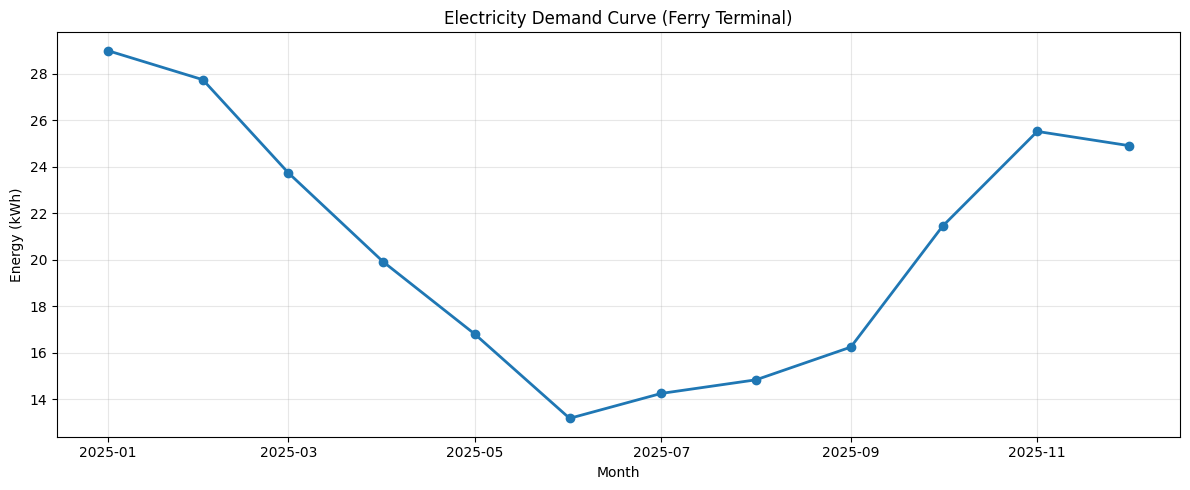

In [8]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = ferryterminal_el_demand_hourly.dropna(subset=["datetime", "energy_kWh"]).copy()
df_plot = df_plot.set_index("datetime").sort_index()

# Monthly demand curve (average energy per month)
monthly_curve = df_plot["energy_kWh"].resample("MS").mean()  # MS = month start

plt.figure(figsize=(12, 5))
plt.plot(monthly_curve.index, monthly_curve.values, marker="o", linewidth=2)
plt.title("Electricity Demand Curve (Ferry Terminal)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

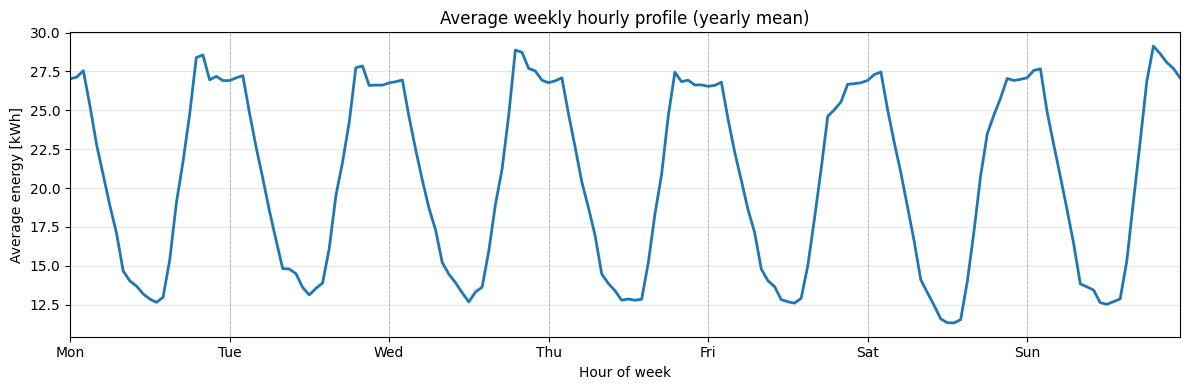

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = ferryterminal_el_demand_hourly.copy()

# 1) Ensure datetime type
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# 2) Build hour-of-week index: Monday 00:00 = 0, ..., Sunday 23:00 = 167
df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour

# 3) Yearly average profile per hour-of-week (168 points)
weekly_profile = (
    df.groupby("hour_of_week")["energy_kWh"]
      .mean()
      .reindex(range(168))  # keep full week order
      .reset_index(name="avg_energy_kWh")
)

# 4) Plot one-week average hourly profile
plt.figure(figsize=(12, 4))
plt.plot(weekly_profile["hour_of_week"], weekly_profile["avg_energy_kWh"], linewidth=2)

# Day separators and labels
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Average energy [kWh]")
plt.title("Average weekly hourly profile (yearly mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converting to kW

In [10]:
from math import sqrt


ferryterminal_power_demand = (
    ferryterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(5000/1630) # scaling factor given by different floor areas of the existing and new terminal (5000 m2 vs 1630 m2)
    .mul(sqrt(3)) # sqrt of 3 because of 3-phase system
    .reset_index()
    .rename(columns={"ampere": "power_kW"})
)

ferryterminal_power_demand.head()


,datetime,power_kW
0,2025-01-01 00:00:00,182.160208
1,2025-01-01 00:15:00,182.008787
2,2025-01-01 00:30:00,183.472529
3,2025-01-01 00:45:00,182.866843
4,2025-01-01 01:00:00,180.393623


In [11]:
DT_H = 0.25  # 15 min

check = ferryterminal_power_demand[["datetime", "power_kW"]].copy()
check["datetime"] = pd.to_datetime(check["datetime"], errors="coerce")
check["power_kW"] = pd.to_numeric(check["power_kW"], errors="coerce")
check = check.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

check["energy_kWh"] = check["power_kW"] * DT_H

n_timesteps = len(check)

idx_max = check["power_kW"].idxmax()
idx_min = check["power_kW"].idxmin()

summary = pd.DataFrame(
    [
        {
            "timesteps": n_timesteps,
            "datetime": check.loc[idx_max, "datetime"],
            "kW": check.loc[idx_max, "power_kW"],
            "kWh": check.loc[idx_max, "energy_kWh"],
        },
        {
            "timesteps": n_timesteps,
            "datetime": check.loc[idx_min, "datetime"],
            "kW": check.loc[idx_min, "power_kW"],
            "kWh": check.loc[idx_min, "energy_kWh"],
        },
        {
            "timesteps": n_timesteps,
            "datetime": pd.NaT,
            "kW": check["power_kW"].mean(),
            "kWh": check["energy_kWh"].mean(),
        },
        {
            "timesteps": n_timesteps,
            "datetime": pd.NaT,
            "kW": check["power_kW"].sum(),
            "kWh": check["energy_kWh"].sum(),
        },
    ],
    index=["max", "min", "mean", "total"],
)

summary

,timesteps,datetime,kW,kWh
max,35039,2025-02-15 19:00:00,3.202567e+02,80.064181
min,35039,2025-10-16 05:30:00,0.000000e+00,0.000000
mean,35039,NaT,1.093674e+02,27.341858
total,35039,NaT,3.832126e+06,958031.376180


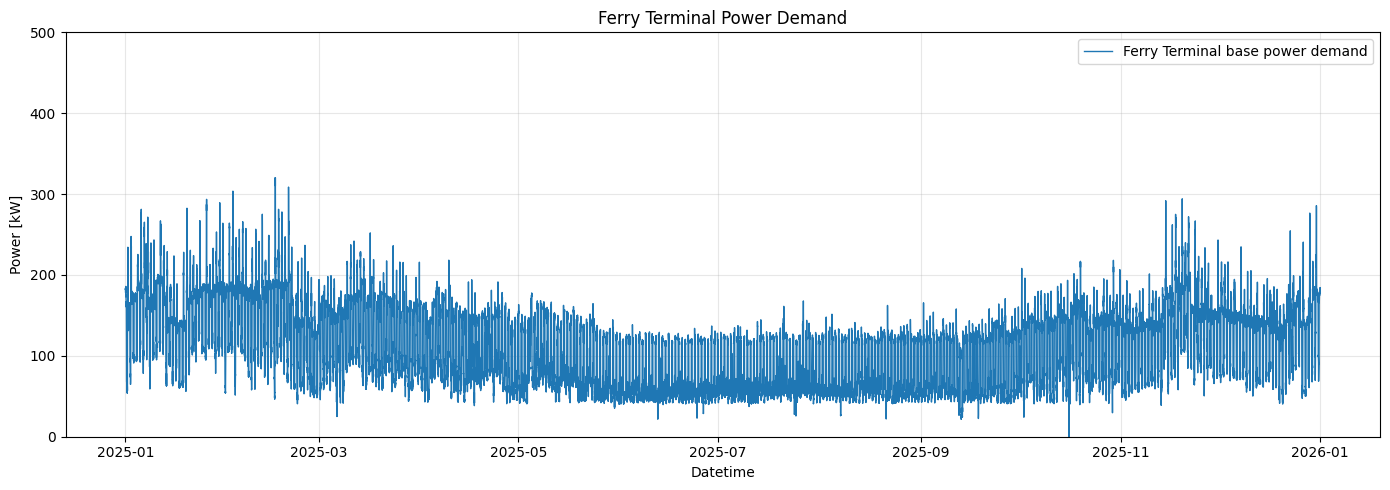

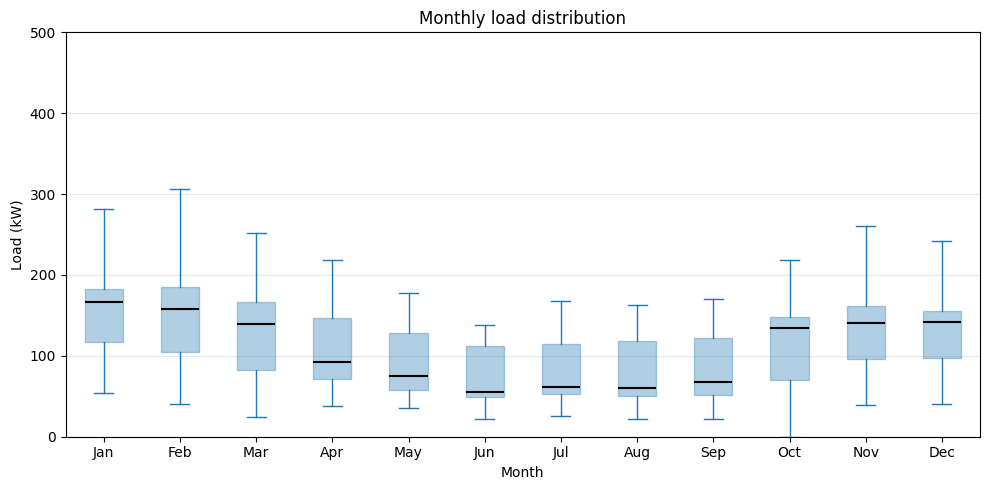

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime is parsed and sorted
df_plot = ferryterminal_power_demand.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

BASE_COLOR = "C0"  # default matplotlib blue (same as the time-series plot above)

# Time series
plt.figure(figsize=(14, 5))
plt.plot(
    df_plot["datetime"],
    df_plot["power_kW"],
    linewidth=1.0,
    color=BASE_COLOR,
    label="Ferry Terminal base power demand",
)
plt.title("Ferry Terminal Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.ylim(0, 500)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Monthly load distribution
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
df_plot["month"] = df_plot["datetime"].dt.month
monthly_load = [df_plot.loc[df_plot["month"] == m, "power_kW"].values for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(monthly_load, tick_labels=month_labels, patch_artist=True, showfliers=False)

for box in bp["boxes"]:
    box.set(facecolor=BASE_COLOR, alpha=0.35, edgecolor=BASE_COLOR)
for whisker in bp["whiskers"]:
    whisker.set(color=BASE_COLOR)
for cap in bp["caps"]:
    cap.set(color=BASE_COLOR)
for median in bp["medians"]:
    median.set(color="black", linewidth=1.5)

ax.set_title("Monthly load distribution")
ax.set_xlabel("Month")
ax.set_ylabel("Load (kW)")
ax.set_ylim(0, 500)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Ships schedule and consumptions

In [13]:
import pandas as pd

# Read Excel and keep only first 3 columns
ships_schedule = pd.read_excel("inputs/passenger_ship_data_Oskarshamn_2025.xlsx").iloc[:, [0, 2, 3]].copy()
ships_schedule.columns = ["ship_name", "arrival_dt", "departure_dt"]

# Parse datetime columns
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"])
ships_schedule["departure_dt"] = pd.to_datetime(ships_schedule["departure_dt"])

# Keep schedule as-is (no month/year shifting)
ships_schedule = ships_schedule.sort_values("arrival_dt").reset_index(drop=True)

ships_schedule.head()

,ship_name,arrival_dt,departure_dt
0,VISBY,2025-01-01 19:15:00,2025-01-01 20:10:00
1,VISBY,2025-01-02 20:00:00,2025-01-02 21:05:00
2,VISBY,2025-01-03 19:15:00,2025-01-03 20:10:00
3,VISBY,2025-01-04 10:40:00,2025-01-04 19:50:00
4,VISBY,2025-01-05 19:15:00,2025-01-05 20:10:00


In [14]:
ships_schedule.tail()

,ship_name,arrival_dt,departure_dt
448,GOTLAND,2025-12-26 19:15:00,2025-12-26 20:10:00
449,GOTLAND,2025-12-27 10:55:00,2025-12-28 11:30:00
450,GOTLAND,2025-12-28 19:15:00,2025-12-28 20:10:00
451,GOTLAND,2025-12-29 20:00:00,2025-12-29 21:05:00
452,VISBY,2025-12-30 20:00:00,2025-12-30 21:05:00


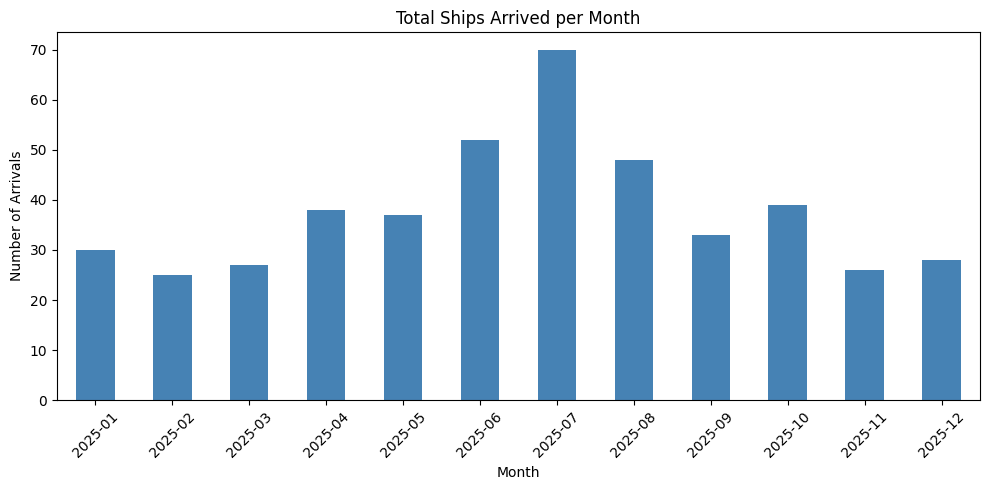

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"], errors="coerce")

# Count arrivals per month
monthly_arrivals = (
    ships_schedule
    .dropna(subset=["arrival_dt"])
    .groupby(ships_schedule["arrival_dt"].dt.to_period("M"))
    .size()
    .rename("arrivals")
)

# Plot
ax = monthly_arrivals.plot(kind="bar", figsize=(10, 5), color="steelblue")
ax.set_title("Total Ships Arrived per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

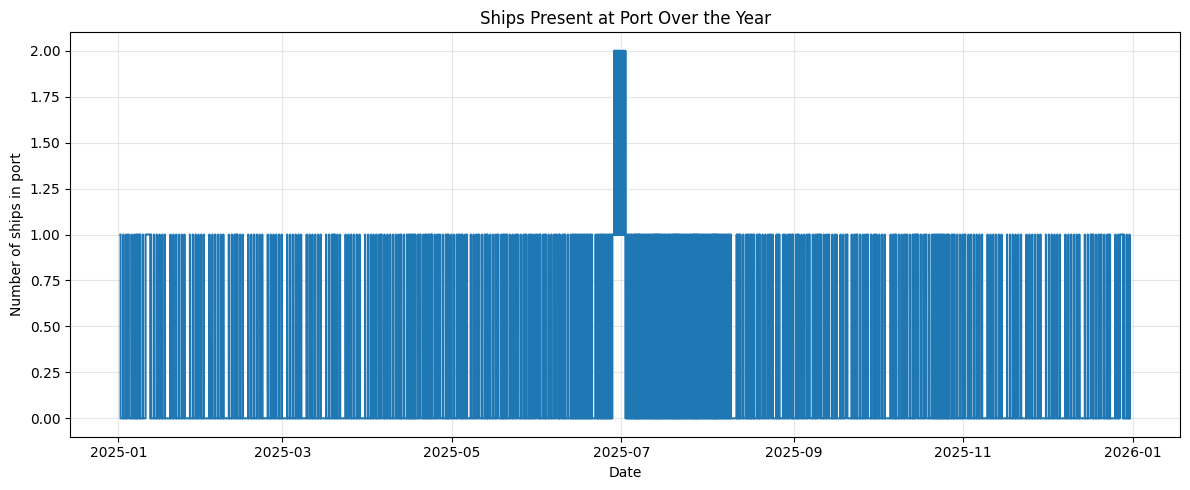

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only valid stays
df = ships_schedule.dropna(subset=["arrival_dt", "departure_dt"]).copy()
df = df[df["departure_dt"] >= df["arrival_dt"]].copy()

# Build +1 event at arrival and -1 event at departure
events = pd.concat([
    df[["arrival_dt"]].rename(columns={"arrival_dt": "time"}).assign(delta=1),
    df[["departure_dt"]].rename(columns={"departure_dt": "time"}).assign(delta=-1),
], ignore_index=True)

# Sort events and compute number of ships in port
events = events.sort_values("time").reset_index(drop=True)
events["ships_in_port"] = events["delta"].cumsum()

# Plot
plt.figure(figsize=(12, 5))
plt.step(events["time"], events["ships_in_port"], where="post")
plt.title("Ships Present at Port Over the Year")
plt.xlabel("Date")
plt.ylabel("Number of ships in port")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import pandas as pd

# Expected input table: one row per ferry stay with:
# - arrival_dt
# - departure_dt
# - ship_name
# Example source variable: ships_schedule

# 1) Prepare intervals
ships_intervals = ships_schedule[["arrival_dt", "departure_dt", "ship_name"]].copy()
ships_intervals["arrival_dt"] = pd.to_datetime(ships_intervals["arrival_dt"])
ships_intervals["departure_dt"] = pd.to_datetime(ships_intervals["departure_dt"])

# Power by ship (kW)
power_map_kw = {
    "VISBY": 1492,
    "GOTLAND": 1494,
    "DROTTEN": 1368,
}
ships_intervals["power_kw"] = ships_intervals["ship_name"].astype(str).str.upper().map(power_map_kw).fillna(900.0)

# 1b) Snap to 15-minute steps (00, 15, 30, 45)
# - arrivals -> previous step (floor)
# - departures -> next step (ceil)
ships_intervals["arrival_dt"] = ships_intervals["arrival_dt"].dt.floor("15min")
ships_intervals["departure_dt"] = ships_intervals["departure_dt"].dt.ceil("15min")

# Optional: drop invalid intervals
ships_intervals = ships_intervals[ships_intervals["departure_dt"] > ships_intervals["arrival_dt"]]

# 2) Define 15-minute window from data
start_step = ships_intervals["arrival_dt"].min().floor("15min")
end_step = ships_intervals["departure_dt"].max().ceil("15min")
step_edges = pd.date_range(start=start_step, end=end_step, freq="15min")

# 3) Build 15-minute occupancy matrix
step_index = step_edges[:-1]
start_col = ships_intervals["arrival_dt"].to_numpy()[:, None]
end_col = ships_intervals["departure_dt"].to_numpy()[:, None]
mask = (step_index.to_numpy()[None, :] >= start_col) & (step_index.to_numpy()[None, :] < end_col)

# Per-ship power multipliers by position in stay:
# - if stay <= 4h: first 15 min = 0.85, last 15 min = 0.85
# - if stay  > 4h:
#   - first 15 min after arrival: 0.425
#   - second 15 min after arrival: 0.85
#   - second-last 15 min before departure: 0.85
#   - last 15 min before departure: 0.425
factors = mask.astype(float)
max_steps_short_stay = int(pd.Timedelta(hours=4) / pd.Timedelta(minutes=15))  # 16 steps

for i in range(factors.shape[0]):
    active_idx = np.flatnonzero(mask[i])
    if active_idx.size == 0:
        continue

    if active_idx.size <= max_steps_short_stay:
        # Short stay profile
        factors[i, active_idx[0]] = 0.85
        factors[i, active_idx[-1]] = 0.85
        continue

    # Long stay profile
    # Arrival ramp
    factors[i, active_idx[0]] = 0.425
    factors[i, active_idx[1]] = 0.85

    # Departure ramp
    factors[i, active_idx[-1]] = 0.425
    factors[i, active_idx[-2]] = 0.85

# When multiple ships overlap, only the latest-arrived stay is energized
arrivals = ships_intervals["arrival_dt"].to_numpy()
active_counts = mask.sum(axis=0)

for j in range(mask.shape[1]):
    if active_counts[j] <= 1:
        continue

    active_rows = np.flatnonzero(mask[:, j])
    winner = active_rows[np.argmax(arrivals[active_rows])]
    factors[active_rows[active_rows != winner], j] = 0.0

# Demand per step = sum(power_kW * factor of active ships)
step_energy_kwh = (factors * ships_intervals["power_kw"].to_numpy()[:, None]).sum(axis=0)

# 4) Final dataset: ships_demand
ships_demand = pd.DataFrame({"datetime": step_index, "demand_kW": step_energy_kwh})

ships_demand.head()

,datetime,demand_kW
0,2025-01-01 19:15:00,1268.2
1,2025-01-01 19:30:00,1492.0
2,2025-01-01 19:45:00,1492.0
3,2025-01-01 20:00:00,1268.2
4,2025-01-01 20:15:00,0.0


In [18]:
ships_demand.max()

datetime     2025-12-30 21:00:00
demand_kW                 1494.0
dtype: object

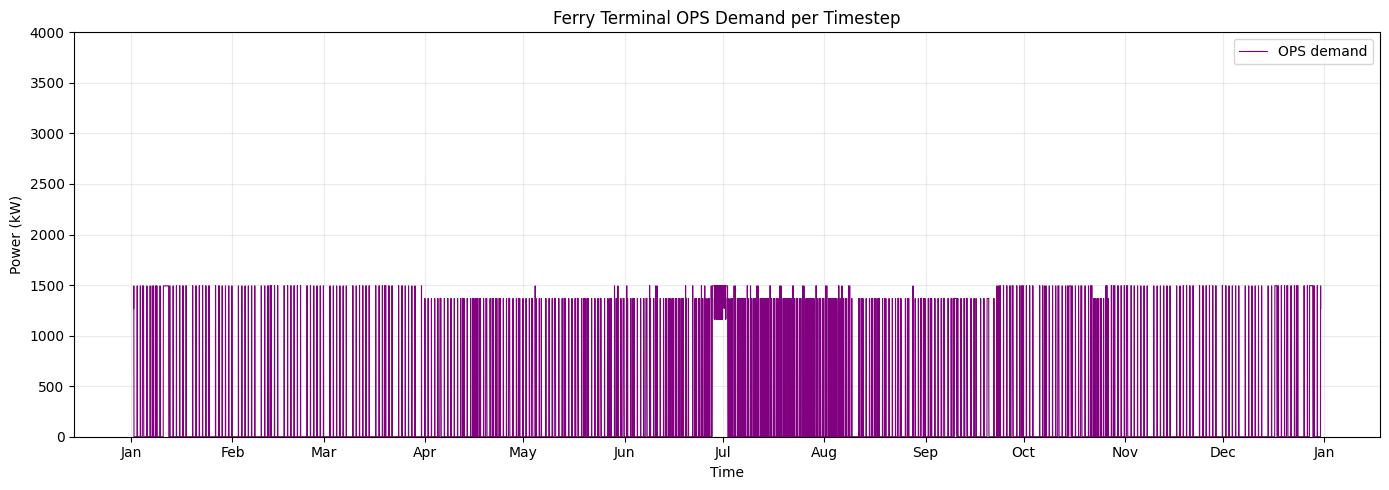

In [19]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ships_demand["datetime"], ships_demand["demand_kW"], color="purple", linewidth=0.8, label="OPS demand")

ax.set_title("Ferry Terminal OPS Demand per Timestep")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.set_ylim(0, 4000)
ax.grid(alpha=0.25)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

In [20]:
ops_kw = ships_demand["demand_kW"]
dt_hours = 0.25  # 15-minute timesteps

# --- Load factor ---
ops_avg_kw = ops_kw.mean()
ops_peak_kw = ops_kw.max()
ops_load_factor = ops_avg_kw / ops_peak_kw if ops_peak_kw > 0 else float("nan")

# --- Utilization factor (berth occupancy / OPS usage) ---
# UF = #(P > 0) / #timesteps
n_timesteps = len(ops_kw)
n_active = (ops_kw > 0).sum()
ops_utilization_factor = n_active / n_timesteps if n_timesteps > 0 else float("nan")

# --- Total yearly demand ---
ops_yearly_kwh = (ops_kw * dt_hours).sum()
ops_yearly_gwh = ops_yearly_kwh / 1e6

print(f"OPS average demand:        {ops_avg_kw:,.1f} kW")
print(f"OPS peak demand:           {ops_peak_kw:,.1f} kW")
print(f"OPS load factor:           {ops_load_factor:.3f}  ({ops_load_factor * 100:.1f}%)")
print(f"Active timesteps (P > 0):  {n_active:,} / {n_timesteps:,}")
print(f"OPS utilization factor:    {ops_utilization_factor:.3f}  ({ops_utilization_factor * 100:.1f}%)")
print(f"OPS yearly demand:         {ops_yearly_gwh:,.3f} GWh")

OPS average demand:        150.2 kW
OPS peak demand:           1,494.0 kW
OPS load factor:           0.101  (10.1%)
Active timesteps (P > 0):  3,818 / 34,856
OPS utilization factor:    0.110  (11.0%)
OPS yearly demand:         1.308 GWh


In [84]:
# Rebuild clean occupancy time series first
events_clean = (
    events.groupby("time", as_index=True)["delta"]
    .sum()
    .sort_index()
    .to_frame()
)
events_clean["ships_in_port"] = events_clean["delta"].cumsum().clip(lower=0)

# Hourly time series (every hour in the year)
hourly_presence = events_clean["ships_in_port"].resample("1h").ffill()

# 1) Average by hour of day (0..23)
avg_by_hour = hourly_presence.groupby(hourly_presence.index.hour).mean()
avg_by_hour.index.name = "hour"

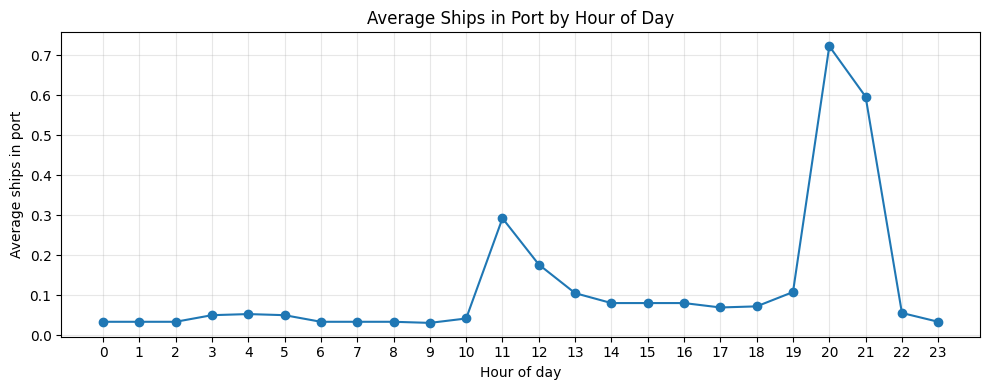

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
avg_by_hour.plot(marker="o")
plt.title("Average Ships in Port by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average ships in port")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Total ship calls (valid stays): 453
Unique ships: 3
Berth duration [h] — mean: 1.96, median: 1.08, min: 0.50, max: 112.85

Arrivals by hour of day:


,hour_of_day,n_ships
0,0,0
1,1,0
2,2,6
3,3,1
4,4,7
5,5,0
6,6,0
7,7,0
8,8,0
9,9,1


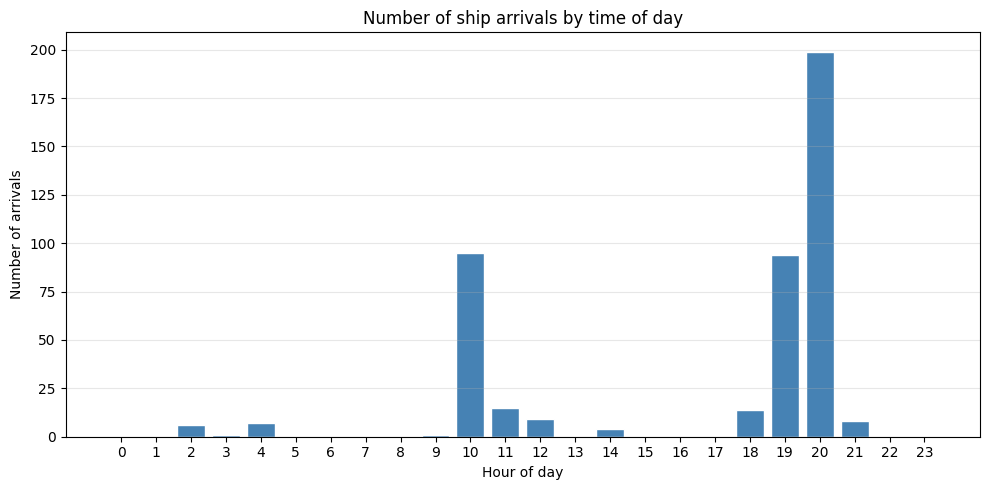

Arrivals by hour of day and ship:


ship_name,DROTTEN,GOTLAND,VISBY
arrival_hour,,,
0,0,0,0
1,0,0,0
2,6,0,0
3,0,0,1
4,6,1,0
5,0,0,0
6,0,0,0
7,0,0,0
8,0,0,0


Ships by berth duration bin:


,duration_bin,n_ships
0,0-1 h,139
1,1-2 h,284
2,2-4 h,0
3,4-8 h,4
4,8-12 h,19
5,12-24 h,4
6,>24 h,3


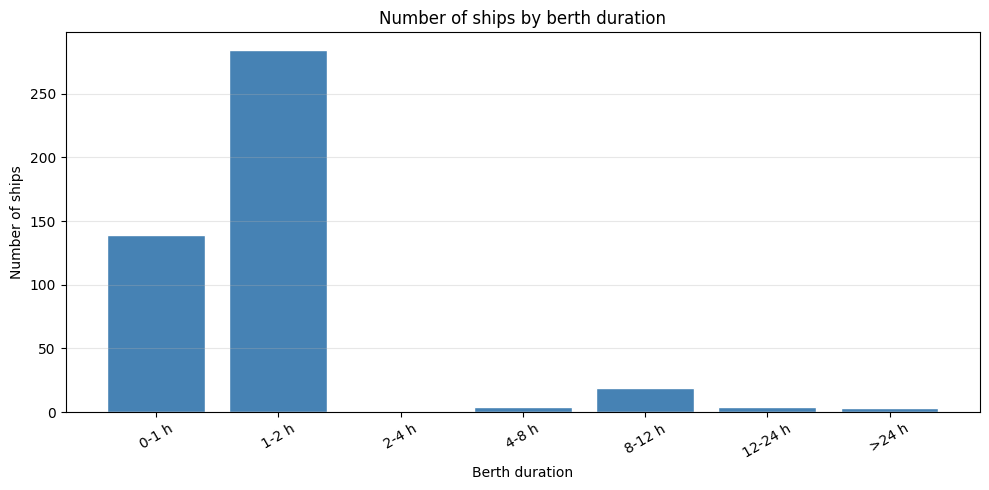


Short vs long stays:


,n_ships
stay_type,
Short stay (<= 4 h),423
Long stay (> 4 h),30


Berth duration statistics by ship:


,n_calls,mean_h,median_h,min_h,max_h
ship_name,,,,,
DROTTEN,241,1.662033,1.083333,0.5,15.766667
VISBY,110,2.811212,1.083333,0.5,112.850000
GOTLAND,102,1.734314,1.083333,0.5,24.583333


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare ship stay table ---
ships_stats = ships_schedule.copy()
ships_stats["arrival_dt"] = pd.to_datetime(ships_stats["arrival_dt"], errors="coerce")
ships_stats["departure_dt"] = pd.to_datetime(ships_stats["departure_dt"], errors="coerce")

ships_stats = (
    ships_stats
    .dropna(subset=["arrival_dt", "departure_dt"])
    .query("departure_dt >= arrival_dt")
    .copy()
)

# Berth duration [hours]
ships_stats["berth_duration_h"] = (
    ships_stats["departure_dt"] - ships_stats["arrival_dt"]
).dt.total_seconds() / 3600.0

# Arrival time of day
ships_stats["arrival_hour"] = ships_stats["arrival_dt"].dt.hour

print(f"Total ship calls (valid stays): {len(ships_stats):,}")
print(f"Unique ships: {ships_stats['ship_name'].nunique()}")
print(f"Berth duration [h] — mean: {ships_stats['berth_duration_h'].mean():.2f}, "
      f"median: {ships_stats['berth_duration_h'].median():.2f}, "
      f"min: {ships_stats['berth_duration_h'].min():.2f}, "
      f"max: {ships_stats['berth_duration_h'].max():.2f}")
print()

# ============================================================
# 1) Number of ships per arrival time of day
# ============================================================
arrivals_by_hour = (
    ships_stats
    .groupby("arrival_hour")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("n_ships")
)

arrivals_by_hour_df = arrivals_by_hour.reset_index()
arrivals_by_hour_df.columns = ["hour_of_day", "n_ships"]

print("Arrivals by hour of day:")
display(arrivals_by_hour_df)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(arrivals_by_hour.index, arrivals_by_hour.values, color="steelblue", edgecolor="white")
ax.set_title("Number of ship arrivals by time of day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Number of arrivals")
ax.set_xticks(range(0, 24))
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: breakdown by ship name
arrivals_by_hour_ship = (
    ships_stats
    .groupby(["arrival_hour", "ship_name"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)

print("Arrivals by hour of day and ship:")
display(arrivals_by_hour_ship)

# ============================================================
# 2) Number of ships per berth duration
# ============================================================

# Option A: fixed duration bins (adjust if needed)
duration_bins = [0, 1, 2, 4, 8, 12, 24, np.inf]
duration_labels = ["0-1 h", "1-2 h", "2-4 h", "4-8 h", "8-12 h", "12-24 h", ">24 h"]

ships_stats["duration_bin"] = pd.cut(
    ships_stats["berth_duration_h"],
    bins=duration_bins,
    labels=duration_labels,
    right=True,
    include_lowest=True,
)

ships_by_duration = (
    ships_stats
    .groupby("duration_bin", observed=False)
    .size()
    .rename("n_ships")
    .reset_index()
)

print("Ships by berth duration bin:")
display(ships_by_duration)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    ships_by_duration["duration_bin"].astype(str),
    ships_by_duration["n_ships"],
    color="steelblue",
    edgecolor="white",
)
ax.set_title("Number of ships by berth duration")
ax.set_xlabel("Berth duration")
ax.set_ylabel("Number of ships")
plt.xticks(rotation=30)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Option B: same split used later in OPS modeling (<= 4 h vs > 4 h)
ships_stats["stay_type"] = np.where(
    ships_stats["berth_duration_h"] <= 4,
    "Short stay (<= 4 h)",
    "Long stay (> 4 h)",
)

stay_type_counts = ships_stats["stay_type"].value_counts().rename("n_ships")
print("\nShort vs long stays:")
display(stay_type_counts.to_frame())

# Optional: duration stats by ship
duration_by_ship = (
    ships_stats
    .groupby("ship_name")["berth_duration_h"]
    .agg(n_calls="count", mean_h="mean", median_h="median", min_h="min", max_h="max")
    .sort_values("n_calls", ascending=False)
)

print("Berth duration statistics by ship:")
display(duration_by_ship)

## 3. Optimization using Gurobi

In [86]:
port_operations = pd.read_excel("inputs/Port_Operations.xlsx")
HM_consumptions_full = pd.read_excel("inputs/HM_consumptions_15minutes.xlsx")

Reads price in EUR/MWh and converts them to SEK (1 EUR = 10.77 SEK) and EUR/kWh

In [87]:
# Read CSV from inputs and keep first + fourth columns
da_price = pd.read_excel("inputs/dayahedprices_15min.xlsx").copy()

da_price.head()

,datetime,da_price
0,2025-01-01 00:00:00,0.034111
1,2025-01-01 00:15:00,0.033426
2,2025-01-01 00:30:00,0.034068
3,2025-01-01 00:45:00,0.034528
4,2025-01-01 01:00:00,0.026369


Only taking ferry terminal related vehicles

In [88]:
import pandas as pd

# Normalize all column names in HM_consumptions
HM = HM_consumptions_full.copy()
HM.columns = (
    HM.columns.astype(str)
    .str.replace("\xa0", "", regex=False)   # remove NBSP
    .str.replace(r"\s+", " ", regex=True)   # normalize repeated spaces
    .str.strip()                            # trim edges
)

selected_cols = [
    "Term.drag 468",
    "Term.drag 469",
    "Term.drag 470",
    "Lastmaskin 430",
    "Lastmaskin 431",
    "Lastmaskin 432",
    "Truck 417",
    "Truck 413",
    "Truck 420",
    "Truck 422",
    "Truck 423",
    "Truck 424",
]

# Keep datetime if present
keep = ["datetime"] + selected_cols

# Optional safety check
missing = [c for c in keep if c not in HM.columns]
print("Missing:", missing)

# Final filtered dataframe
HM_consumptions_ferryterminal = HM[[c for c in keep if c in HM.columns]].copy()

Missing: []


In [89]:
import numpy as np
import pandas as pd

# -----------------------------
# Assumed existing in notebook:
# - ferryterminal_power_demand: columns ["datetime", "power_kW"]
# - HM_consumptions: columns ["datetime", <vehicle IDs...>] (kWh per hour)
# - port_operations: columns ["ID", "Battery Capacity (kWh)", "Fast Charge Capacity (kW)",
#                             "Requires charging during operation"]
# -----------------------------

# --- Time set T (15-minute) built from ferry terminal + ships demand in kW ---
# ferryterminal_power_demand expected columns: ["datetime", "power_kW"]
base_kw = ferryterminal_power_demand[["datetime", "power_kW"]].copy()
base_kw["datetime"] = pd.to_datetime(base_kw["datetime"], errors="coerce")
base_kw["power_kW"] = pd.to_numeric(base_kw["power_kW"], errors="coerce")
base_kw = (
    base_kw
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# ships_demand expected to provide one of: demand_kW, demand_kWh, demand_mwh, energy_kWh
ships_kw = ships_demand.copy()
ships_kw["datetime"] = pd.to_datetime(ships_kw["datetime"], errors="coerce")

if "demand_kW" in ships_kw.columns:
    ships_kw["ships_kW"] = pd.to_numeric(ships_kw["demand_kW"], errors="coerce")

ships_kw = (
    ships_kw[["datetime", "ships_kW"]]
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# Merge timestep-by-timestep at 15-minute resolution
full_idx = pd.date_range(
    start=min(base_kw["datetime"].min(), ships_kw["datetime"].min()),
    end=max(base_kw["datetime"].max(), ships_kw["datetime"].max()),
    freq="15min"
)

T_df = (
    pd.DataFrame({"datetime": full_idx})
    .merge(base_kw, on="datetime", how="left")
    .merge(ships_kw, on="datetime", how="left")
)
T_df["power_kW"] = T_df["power_kW"].fillna(0.0)
T_df["ships_kW"] = T_df["ships_kW"].fillna(0.0)
T_df["total_kW"] = T_df["power_kW"] + T_df["ships_kW"]

T = T_df["datetime"].to_list()

# Fixed terminal demand D[t] in kW
D_kw = T_df.set_index("datetime")["total_kW"].to_dict()

# Helpful index maps
t2i = {t: i for i, t in enumerate(T)}
i2t = {i: t for t, i in t2i.items()}

# --- Vehicle set V from port_operations (Step 24=C) ---
po = port_operations.copy()
po["ID"] = po["ID"].astype(str)

# drop duplicates just in case
po = po.drop_duplicates(subset=["ID"], keep="first").set_index("ID")

V = po.index.to_list()

# Vehicle parameters
Cap_kwh = po["Battery Capacity (kWh)"].astype(float).to_dict()

eligible = (
    po["Requires charging during operation"]
    .notna()
    .to_dict()
)

Pfast_kw = po["Fast Charge Capacity (kW)"].astype(float).fillna(0.0).to_dict()

# --- Consumption Econs[v,t] (kWh) aligned to V x T ---
hm = HM_consumptions_ferryterminal.copy()
hm["datetime"] = pd.to_datetime(hm["datetime"])
hm = hm.dropna(subset=["datetime"]).drop_duplicates(subset=["datetime"]).set_index("datetime").sort_index()

# Reindex to T and ensure all vehicles exist as columns (missing -> 0)
hm = hm.reindex(T, fill_value=0.0)
for v in V:
    if v not in hm.columns:
        hm[v] = 0.0

# Keep only vehicles in V (extra columns ignored)
hm = hm[V].astype(float)

# Dict keyed by (v,t) for easy modeling
Econs_kwh = {(v, t): float(hm.loc[t, v]) for t in T for v in V}

# --- Time window masks ---
slow_hours = {20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6}   # do NOT include 7
fast_hours = {9, 12, 15}                              # 9-10, 12-13, 15-16

is_slow = {t: (t.hour in slow_hours) for t in T}
is_fast = {t: (t.hour in fast_hours) for t in T}
is_allowed = {t: (is_slow[t] or is_fast[t]) for t in T}

T07 = [t for t in T if (t.hour == 7 and t.minute == 0)]

# --- Sanity checks ---
print(f"|T| = {len(T)} 15 minutes steps from {T[0]} to {T[-1]}")
print(f"|V| = {len(V)} vehicles")
print(f"07:00 checkpoints in T: {len(T07)}")
print(f"Allowed charging hours in T: {sum(is_allowed.values())} (slow={sum(is_slow.values())}, fast={sum(is_fast.values())})")

# Verify no consumption after 20:00 (per your assumption)
after20 = [(v, t, Econs_kwh[(v, t)]) for t in T if t.hour >= 20 for v in V if Econs_kwh[(v, t)] > 0]
print(f"Consumption entries with hour>=20 and >0 kWh: {len(after20)}")
if after20:
    print("Example:", after20[0])

|T| = 35040 15 minutes steps from 2025-01-01 00:00:00 to 2025-12-31 23:45:00
|V| = 32 vehicles
07:00 checkpoints in T: 365
Allowed charging hours in T: 20440 (slow=16060, fast=4380)
Consumption entries with hour>=20 and >0 kWh: 0


In [90]:
import pandas as pd
import pyomo.environ as pyo

# -----------------------------
# Uses objects created earlier:
# T, V, t2i, i2t
# D_kw, Cap_kwh, eligible, Pfast_kw
# Econs_kwh
# is_slow, is_fast, is_allowed
# T07
# da_price DataFrame with columns: datetime, da_price
# -----------------------------

P_slow = 22.0
dt = 0.25  # hours (15 min)

T_idx = list(range(len(T)))
next_i = {i: i + 1 for i in T_idx[:-1]}

# ---------- PRICE MAPPING ----------
price_df = da_price.copy()
price_df["datetime"] = pd.to_datetime(price_df["datetime"], errors="coerce").dt.tz_localize(None)
price_df["da_price"] = pd.to_numeric(price_df["da_price"], errors="coerce")

price_series = (
    price_df.dropna(subset=["datetime", "da_price"])
            .sort_values("datetime")
            .drop_duplicates("datetime", keep="last")
            .set_index("datetime")["da_price"]
)

# Build model timestep index and align prices to it
t_index = pd.DatetimeIndex(pd.to_datetime(T)).tz_localize(None)
price_on_T = price_series.reindex(t_index)

# Fill possible gaps from neighboring timesteps (remove if you want strict fail)
price_on_T = price_on_T.ffill().bfill()

# Strict safety check (after fill)
if price_on_T.isna().any():
    missing = list(price_on_T[price_on_T.isna()].index[:10])
    raise ValueError(f"Missing da_price for timestamps (examples): {missing}")

# Final mapping used in objective
price_t = {t: float(v) for t, v in zip(T, price_on_T.values)}

T07_i = [t2i[t] for t in T07]
FAST_I = [t2i[t] for t in T if is_fast[t]]

soc_max_frac = 1
soc_min_frac = 0.1

# Stage-3 shaping and stage-4 price flexibility
SMOOTHNESS_REL_TOL = 0.05
SHAPE_WEIGHT = 8.0
SHIP_CHARGE_WEIGHT = 20.0
MAX_EV_RAMP_UP_KW = 20.0
HIGH_POWER_THRESHOLD_KW = 100.0
HIGH_POWER_WEIGHT = 30.0

base_kw_by_dt = T_df.set_index("datetime")["power_kW"].to_dict()
base_kw_by_i = {
    i: float(base_kw_by_dt.get(i2t[i], 0.0))
    for i in T_idx
}

ships_kw_by_dt = T_df.set_index("datetime")["ships_kW"].to_dict()
ships_kw_by_i = {
    i: float(ships_kw_by_dt.get(i2t[i], 0.0))
    for i in T_idx
}
ship_penalty_active = {
    i: (1.0 if ships_kw_by_i[i] > 0.0 else 0.0)
    for i in T_idx
}

m = pyo.ConcreteModel("vehicle_charging_peak_min_cost")

# Sets
m.V = pyo.Set(initialize=list(V))
m.I = pyo.Set(initialize=T_idx, ordered=True)
m.I_dyn = pyo.Set(initialize=T_idx[:-1], ordered=True)
m.FAST_I = pyo.Set(initialize=FAST_I, ordered=True)
m.T07_I = pyo.Set(initialize=T07_i, ordered=True)

# Variables
m.P = pyo.Var(m.V, m.I, domain=pyo.NonNegativeReals)         # kW
m.SOC = pyo.Var(m.V, m.I, domain=pyo.Reals)                  # bounds via constraints
m.P_peak = pyo.Var(domain=pyo.NonNegativeReals)
m.y_fast = pyo.Var(m.V, m.FAST_I, domain=pyo.Binary)

# SOC bounds
def soc_lb_rule(mm, v, i):
    return mm.SOC[v, i] >= float(Cap_kwh[v]) * soc_min_frac
m.soc_lb = pyo.Constraint(m.V, m.I, rule=soc_lb_rule)

def soc_ub_rule(mm, v, i):
    return mm.SOC[v, i] <= float(Cap_kwh[v]) * soc_max_frac
m.soc_ub = pyo.Constraint(m.V, m.I, rule=soc_ub_rule)

# Initial SOC = 100%
i0 = 0
def init_soc_rule(mm, v):
    return mm.SOC[v, i0] == float(Cap_kwh[v]) * soc_max_frac
m.init_soc = pyo.Constraint(m.V, rule=init_soc_rule)

# SOC dynamics
def soc_dyn_rule(mm, v, i):
    t = i2t[i]
    cons = float(Econs_kwh[(v, t)])
    return mm.SOC[v, next_i[i]] == mm.SOC[v, i] + mm.P[v, i] * dt - cons
m.soc_dyn = pyo.Constraint(m.V, m.I_dyn, rule=soc_dyn_rule)

# Fast charging limit to 5 vehicles at a time
def fast_limit_rule(mm, i):
    return sum(mm.y_fast[v, i] for v in mm.V) <= 4
m.fast_limit = pyo.Constraint(m.FAST_I, rule=fast_limit_rule)

# Time-dependent charging caps + no charge while consuming
m.charge_cons = pyo.ConstraintList()
for v in V:
    for i in T_idx:
        t = i2t[i]

        # No charging while consuming
        if float(Econs_kwh[(v, t)]) > 0.0:
            m.charge_cons.add(m.P[v, i] == 0.0)
            continue

        if not is_allowed[t]:
            m.charge_cons.add(m.P[v, i] == 0.0)
            continue

        if is_slow[t]:
            m.charge_cons.add(m.P[v, i] <= P_slow)
            continue

        if is_fast[t]:
            if eligible.get(v, False):
                m.charge_cons.add(
                    m.P[v, i] <= P_slow + (float(Pfast_kw[v]) - P_slow) * m.y_fast[v, i]
                )
            else:
                m.charge_cons.add(m.P[v, i] <= P_slow)
                m.charge_cons.add(m.y_fast[v, i] == 0.0)

# Prevent overfilling battery
def no_overfill_rule(mm, v, i):
    cap = float(Cap_kwh[v])
    return mm.P[v, i] * dt <= cap - mm.SOC[v, i]
m.no_overfill = pyo.Constraint(m.V, m.I, rule=no_overfill_rule)

# Hard target by 07:00 at SOC ceiling
def min07_rule(mm, v, i):
    target = float(Cap_kwh[v]) * soc_max_frac
    return mm.SOC[v, i] >= target
m.min07 = pyo.Constraint(m.V, m.T07_I, rule=min07_rule)

# Peak definition
def peak_def_rule(mm, i):
    t = i2t[i]
    fixed = float(D_kw[t])
    return fixed + sum(mm.P[v, i] for v in mm.V) <= mm.P_peak
m.peak_def = pyo.Constraint(m.I, rule=peak_def_rule)

# Aggregate charging profile and smoothness metrics
def p_tot_rule(mm, i):
    return sum(mm.P[v, i] for v in mm.V)
m.P_tot = pyo.Expression(m.I, rule=p_tot_rule)

def l_base_ev_rule(mm, i):
    return float(base_kw_by_i[i]) + mm.P_tot[i]
m.L_base_ev = pyo.Expression(m.I, rule=l_base_ev_rule)

m.ev_ramp_up = pyo.Var(m.I_dyn, domain=pyo.NonNegativeReals)
m.term_ramp_up = pyo.Var(m.I_dyn, domain=pyo.NonNegativeReals)
m.ev_excess = pyo.Var(m.I, domain=pyo.NonNegativeReals)
m.dev = pyo.Var(m.I, domain=pyo.NonNegativeReals)
m.P_ref = pyo.Param(m.I, within=pyo.NonNegativeReals, mutable=True, initialize=0.0)
m.ship_penalty_active = pyo.Param(
    m.I,
    within=pyo.NonNegativeReals,
    initialize=ship_penalty_active,
    mutable=False,
)

def ev_ramp_up_rule(mm, i):
    return mm.ev_ramp_up[i] >= mm.P_tot[i + 1] - mm.P_tot[i]
m.ev_ramp_up_def = pyo.Constraint(m.I_dyn, rule=ev_ramp_up_rule)

def term_ramp_up_rule(mm, i):
    return mm.term_ramp_up[i] >= mm.L_base_ev[i + 1] - mm.L_base_ev[i]
m.term_ramp_up_def = pyo.Constraint(m.I_dyn, rule=term_ramp_up_rule)

m.high_power_cons = pyo.ConstraintList()
for i in T_idx:
    m.high_power_cons.add(
        m.ev_excess[i] >= m.P_tot[i] - HIGH_POWER_THRESHOLD_KW
    )

m.ev_ramp_up_cap = pyo.ConstraintList()
for i in m.I_dyn:
    m.ev_ramp_up_cap.add(
        m.P_tot[i + 1] - m.P_tot[i] <= MAX_EV_RAMP_UP_KW
    )

m.dev_cons = pyo.ConstraintList()
for i in T_idx:
    if is_allowed[i2t[i]]:
        m.dev_cons.add(m.dev[i] >= m.P_tot[i] - m.P_ref[i])
        m.dev_cons.add(m.dev[i] >= m.P_ref[i] - m.P_tot[i])
    else:
        m.dev_cons.add(m.dev[i] == 0.0)

# Expressions
m.total_energy = pyo.Expression(
    expr=sum(m.P[v, i] * dt for v in V for i in T_idx)
)
m.total_charging_cost = pyo.Expression(
    expr=sum(m.P[v, i] * dt * price_t[i2t[i]] for v in V for i in T_idx)
)
m.total_ev_ramp_up = pyo.Expression(expr=sum(m.ev_ramp_up[i] for i in m.I_dyn))
m.total_term_ramp_up = pyo.Expression(expr=sum(m.term_ramp_up[i] for i in m.I_dyn))
m.total_high_charge = pyo.Expression(expr=sum(m.ev_excess[i] for i in T_idx))
m.total_dev = pyo.Expression(expr=sum(m.dev[i] for i in T_idx))
m.total_ship_charge = pyo.Expression(
    expr=sum(m.P_tot[i] * m.ship_penalty_active[i] for i in T_idx)
)
m.total_smoothness = pyo.Expression(
    expr=(
        SHAPE_WEIGHT
        * (
            m.total_ev_ramp_up
            + m.total_term_ramp_up
            + m.total_dev
        )
        + SHIP_CHARGE_WEIGHT * m.total_ship_charge
        + HIGH_POWER_WEIGHT * m.total_high_charge
    )
)

# ---------- Lexicographic solve (4 stages) ----------
solver = pyo.SolverFactory("gurobi")
solver.options["TimeLimit"] = 360
solver.options["MIPGap"] = 1e-3
solver.options["Threads"] = 0

# Stage 1: minimize peak
m.obj_peak = pyo.Objective(expr=m.P_peak, sense=pyo.minimize)
solver.solve(m, tee=False)
peak_star = pyo.value(m.P_peak)

# Fix peak at optimum (or epsilon above)
m.fix_peak = pyo.Constraint(expr=m.P_peak <= peak_star + 1e-6)
m.del_component(m.obj_peak)

# Stage 2: minimize total energy
m.obj_energy = pyo.Objective(expr=m.total_energy, sense=pyo.minimize)
solver.solve(m, tee=False)
energy_star = pyo.value(m.total_energy)

# Fix energy at optimum (or epsilon below)
m.fix_energy = pyo.Constraint(expr=m.total_energy <= energy_star + 1e-6)
m.del_component(m.obj_energy)

# Stage 3: flat EV charging with slight base-load adaptation
allowed_i = [i for i in T_idx if is_allowed[i2t[i]]]

for i in T_idx:
    m.P_ref[i] = 0.0

if allowed_i and energy_star > 0.0:
    flat_kw = energy_star / (len(allowed_i) * dt)
    base_max = max(base_kw_by_i[i] for i in allowed_i)
    base_slack = {
        i: (base_max - base_kw_by_i[i] + 1e-6)
        for i in allowed_i
    }
    base_slack_sum = sum(base_slack.values())
    for i in allowed_i:
        adapt_kw = energy_star * base_slack[i] / (base_slack_sum * dt)
        m.P_ref[i] = 0.85 * flat_kw + 0.15 * adapt_kw

m.obj_smooth = pyo.Objective(expr=m.total_smoothness, sense=pyo.minimize)
solver.solve(m, tee=False)
smooth_star = pyo.value(m.total_smoothness)

smooth_tol = max(1.0, SMOOTHNESS_REL_TOL * smooth_star)
m.fix_smooth = pyo.Constraint(expr=m.total_smoothness <= smooth_star + smooth_tol)
m.del_component(m.obj_smooth)

# Stage 4: slightly shift charging toward favorable prices
m.obj_cost = pyo.Objective(expr=m.total_charging_cost, sense=pyo.minimize)

res = solver.solve(m, tee=False)
term = res.solver.termination_condition
status = res.solver.status
if (status == pyo.SolverStatus.ok) and (term in [pyo.TerminationCondition.optimal, pyo.TerminationCondition.feasible]):
    print("P_peak (kW):", pyo.value(m.P_peak))
    print("Total charged energy (kWh):", pyo.value(m.total_energy))
    print("Total charging cost:", pyo.value(m.total_charging_cost))
else:
    print("Solver status:", status)
    print("Termination:", term)

P_peak (kW): 1796.4899232484618
Total charged energy (kWh): 397219.9999996891
Total charging cost: 155810.47727336036


In [91]:
print("Total charging cost:", (pyo.value(m.total_charging_cost)*1.0561)+(0.025*pyo.value(m.total_energy)))

Total charging cost: 174481.94504838812


In [111]:
import pandas as pd

DT_H = 0.25
EV_ZERO_TOL = 1.0000001111620804e-06  # numerical noise at optimized peak

def compute_peak_impact_metrics(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    # Treat negligible EV as exactly zero
    if "EV_charging_kw" in df.columns:
        ev_kw = df["EV_charging_kw"].where(
            df["EV_charging_kw"].abs() > EV_ZERO_TOL, 0.0
        )
    else:
        ev_kw = df["total_kW"] - (
            df["base_demand_kw"] + df["shore_power_demand_kw"]
        )

    load_no = df["base_demand_kw"] + df["shore_power_demand_kw"]
    load_with = load_no + ev_kw  # rebuild total from cleaned EV

    idx_peak_with = load_with.idxmax()

    peak_no = float(load_no.max())
    peak_with = float(load_with.max())
    peak_increase = peak_with - peak_no

    if abs(peak_increase) <= EV_ZERO_TOL:
        peak_increase = 0.0
        peak_with = peak_no

    return {
        "peak_no_charging_kw": peak_no,
        "peak_with_charging_kw": peak_with,
        "peak_increase_kw": peak_increase,
        "ev_kw_at_system_peak": float(ev_kw.loc[idx_peak_with]),
    }


if "df_opt" not in globals():
    df_opt = pd.read_excel("outputs/ferryterminal_loadshifting.xlsx")  # optimized file for this notebook

peak_summary = compute_peak_impact_metrics(df_opt)
print(peak_summary)

{'peak_no_charging_kw': 1796.4899222484617, 'peak_with_charging_kw': 1796.4899222484617, 'peak_increase_kw': 0.0, 'ev_kw_at_system_peak': 0.0}


## 4. Results export and visualization

In [92]:
from pathlib import Path

# Cursor/VS Code notebooks usually expose this variable
nb_file = globals().get("__vsc_ipynb_file__")

if not nb_file:
    raise RuntimeError(
        "Notebook filename is not exposed in this runtime (__vsc_ipynb_file__ missing)."
    )

notebook_name = Path(nb_file).stem
results_out_path = f"outputs/{notebook_name}.xlsx"

In [93]:
import os
from pathlib import Path
import pandas as pd
import pyomo.environ as pyo

# Build demand components at 15-minute resolution:
# datetime, base demand, shore power demand, EV charging, total.
if not hasattr(m, "P"):
    raise RuntimeError("Model variable m.P was not found. Run the fleet optimization first.")

if "T_df" not in globals():
    raise RuntimeError("T_df was not found. Run the time-series preparation cells first.")

vehicle_444 = "Truck 444 Krokmaskin"
use_m444 = (
    "m_444" in globals()
    and hasattr(m_444, "P")
    and vehicle_444 in V
)

# Demand components from pre-built time series (kW)
base_by_dt = T_df.set_index("datetime")["power_kW"].to_dict()
shore_by_dt = T_df.set_index("datetime")["ships_kW"].to_dict()

rows = []
for i in T_idx:
    t = pd.to_datetime(i2t[i])
    ev_charge_kw = 0.0

    for v in V:
        if use_m444 and v == vehicle_444:
            ev_charge_kw += float(pyo.value(m_444.P[v, i]))
        else:
            ev_charge_kw += float(pyo.value(m.P[v, i]))

    base_kw = float(base_by_dt.get(t, 0.0))
    shore_kw = float(shore_by_dt.get(t, 0.0))
    total_kw = base_kw + shore_kw + ev_charge_kw

    rows.append({
        "datetime": t,
        "base_demand_kw": base_kw,
        "shore_power_demand_kw": shore_kw,
        "EV_charging_kw": ev_charge_kw,
        "total_kW": total_kw,
    })

df_total_charging_15min = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

os.makedirs("outputs", exist_ok=True)
df_total_charging_15min.to_excel(results_out_path, index=False)

print("Wrote:", results_out_path)
print(
    "Source for Truck 444:",
    "m_444" if use_m444 else "m (fallback if m_444 not available)"
)

Wrote: outputs/ferryterminal_loadshifting.xlsx
Source for Truck 444: m (fallback if m_444 not available)


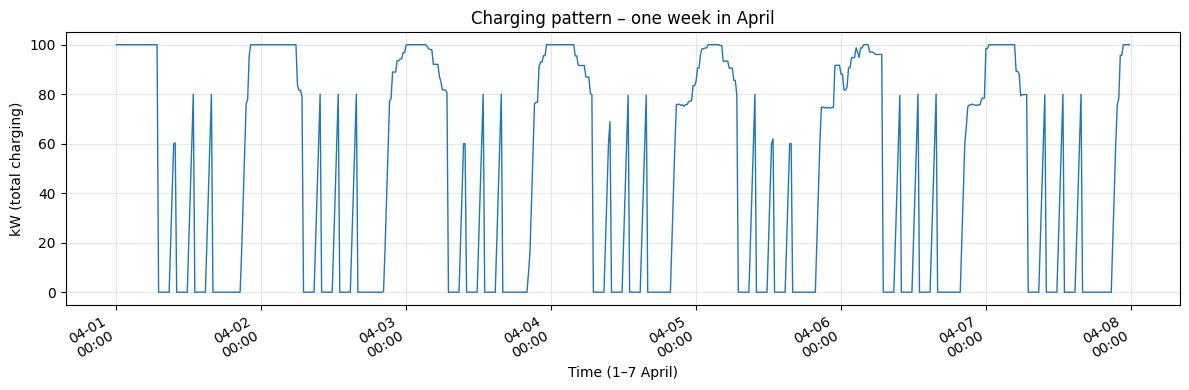

In [94]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyomo.environ as pyo

# Same base series
x_all = [i2t[i] for i in T_idx]
p_total_all = [float(sum(pyo.value(m.P[v, i]) for v in V)) for i in T_idx]

# Define one week in April (here: 1–7 April)
year = x_all[0].year  # assumes all in same year
start = dt.datetime(year, 4, 1)
end   = dt.datetime(year, 4, 8)  # exclusive upper bound

x_week = []
p_week = []
for t, p in zip(x_all, p_total_all):
    if start <= t < end:
        x_week.append(t)
        p_week.append(p)

plt.figure(figsize=(12, 4))
plt.plot(x_week, p_week, lw=1, color="tab:blue")

plt.ylabel("kW (total charging)")
plt.xlabel("Time (1–7 April)")
plt.title("Charging pattern – one week in April")
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

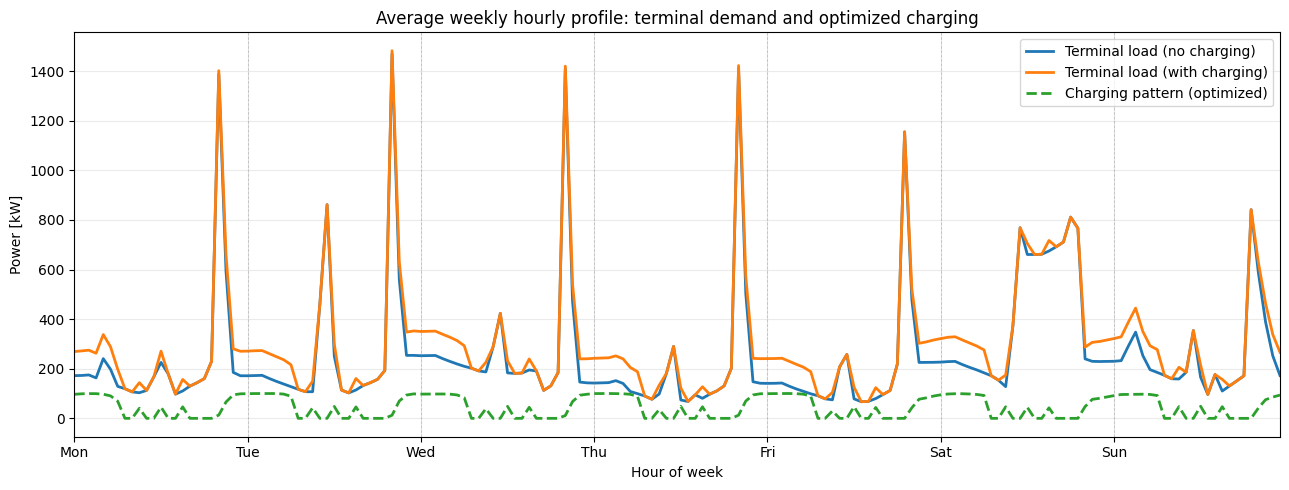

In [95]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REQUIRED_COLS = (
    "datetime",
    "base_demand_kw",
    "shore_power_demand_kw",
    "total_kW",
)


def load_optimization_results():
    if "df_total_charging_15min" in globals():
        candidate = df_total_charging_15min.copy()
        if all(col in candidate.columns for col in REQUIRED_COLS):
            return candidate

    notebook_dir = None
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        notebook_dir = Path(nb_file).resolve().parent

    search_paths = []
    if "results_out_path" in globals():
        search_paths.append(Path(results_out_path))
    if notebook_dir is not None:
        search_paths.append(notebook_dir / "outputs" / "ferryterminal_loadshifting.xlsx")

    seen = set()
    for path in search_paths:
        resolved = path.expanduser()
        if not resolved.is_absolute() and notebook_dir is not None:
            resolved = notebook_dir / resolved
        resolved = resolved.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if not resolved.is_file():
            continue

        candidate = pd.read_excel(resolved)
        missing = [col for col in REQUIRED_COLS if col not in candidate.columns]
        if missing:
            raise KeyError(
                f"{resolved} is missing columns {missing}. Found: {list(candidate.columns)}"
            )
        return candidate

    raise RuntimeError(
        "Optimization export not found. Run the results export cell first, "
        "or place ferryterminal_loadshifting.xlsx in the outputs/ folder next to this notebook."
    )


df_opt = load_optimization_results()

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")

# 2) Terminal load with and without optimized EV charging
df_opt["terminal_load_no_charging_kw"] = (
    df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
)
df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Hour of week (0..167)
df_opt["hour_of_week"] = df_opt["datetime"].dt.dayofweek * 24 + df_opt["datetime"].dt.hour

# 4) Weekly average profiles
weekly = (
    df_opt.groupby("hour_of_week")[[
        "terminal_load_no_charging_kw",
        "terminal_load_with_charging_kw",
        "charging_kw"
    ]]
    .mean()
    .reindex(range(168))
    .reset_index()
)

# 5) Plot combined
plt.figure(figsize=(13, 5))

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_no_charging_kw"],
    label="Terminal load (no charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_with_charging_kw"],
    label="Terminal load (with charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["charging_kw"],
    label="Charging pattern (optimized)",
    linewidth=2,
    linestyle="--"
)

# Day separators
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Power [kW]")
plt.title("Average weekly hourly profile: terminal demand and optimized charging")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

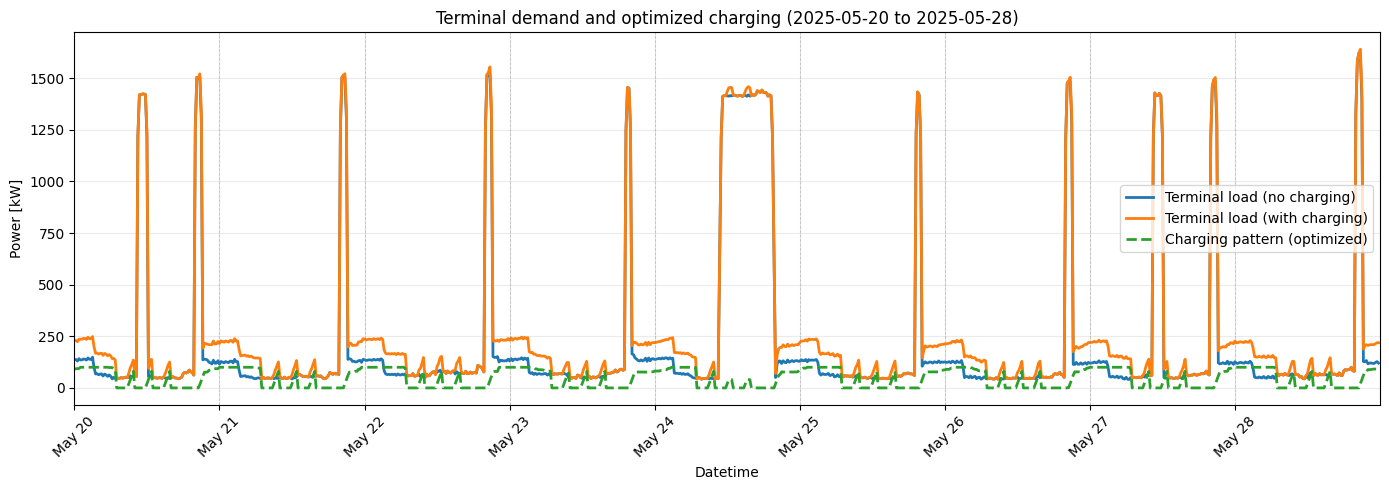

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Use the optimization export built in the previous results cell.
if "df_total_charging_15min" in globals():
    df_opt = df_total_charging_15min.copy()
elif "results_out_path" in globals():
    df_opt = pd.read_excel(results_out_path)
else:
    raise RuntimeError(
        "Optimization export not found. Run the results export cell first."
    )

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")

# 2) Terminal load with and without optimized EV charging
df_opt["terminal_load_no_charging_kw"] = (
    df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
)
df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Filter exact period (inclusive start, inclusive end date)
start = pd.Timestamp("2025-05-20 00:00:00")
end   = pd.Timestamp("2025-05-28 23:59:59")
period = df_opt[(df_opt["datetime"] >= start) & (df_opt["datetime"] <= end)].copy()

if period.empty:
    print("No data found in the selected period.")
else:
    plt.figure(figsize=(14, 5))

    plt.plot(
        period["datetime"],
        period["terminal_load_no_charging_kw"],
        label="Terminal load (no charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["terminal_load_with_charging_kw"],
        label="Terminal load (with charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["charging_kw"],
        label="Charging pattern (optimized)",
        linewidth=2,
        linestyle="--"
    )

    # Day separators + daily ticks
    day_starts = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
    for x in day_starts:
        plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

    plt.xticks(day_starts, [d.strftime("%b %d") for d in day_starts], rotation=45)
    plt.xlim(start, end)
    plt.xlabel("Datetime")
    plt.ylabel("Power [kW]")
    plt.title("Terminal demand and optimized charging (2025-05-20 to 2025-05-28)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

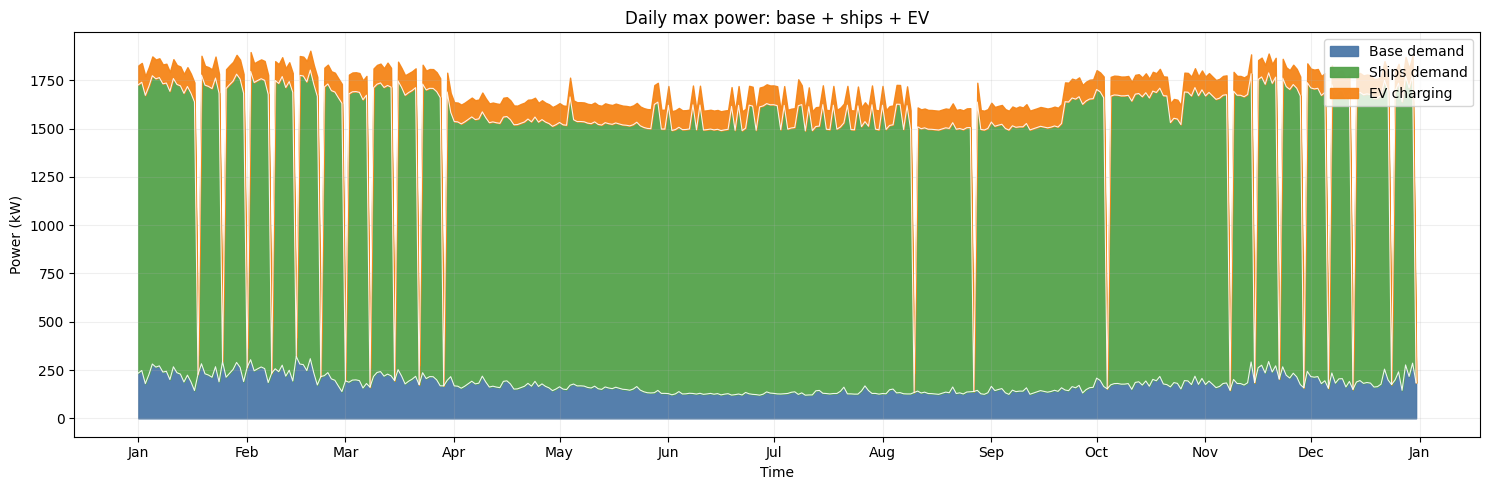

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "outputs/ferryterminal_loadshifting.xlsx"

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Daily aggregation
d = (df.set_index(TIME_COL)[[BASE_COL, SHIP_COL, EV_COL]]
       .resample("D").max()
       .reset_index())

# Cumulative levels
base_top = d[BASE_COL]
ship_top = d[BASE_COL] + d[SHIP_COL]
total    = d[BASE_COL] + d[SHIP_COL] + d[EV_COL]

fig, ax = plt.subplots(figsize=(15, 5))

# Level 1: base
ax.fill_between(d[TIME_COL], 0, base_top, color="#4C78A8", alpha=0.95, label="Base demand")

# Level 2: ships
ax.fill_between(d[TIME_COL], base_top, ship_top, color="#54A24B", alpha=0.95, label="Ships demand")

# Level 3: EV
ax.fill_between(d[TIME_COL], ship_top, total, color="#F58518", alpha=0.95, label="EV charging")

# Optional separators
ax.plot(d[TIME_COL], base_top, color="white", lw=0.8, alpha=0.9)
ax.plot(d[TIME_COL], ship_top, color="white", lw=0.8, alpha=0.9)

ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Daily max power: base + ships + EV")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

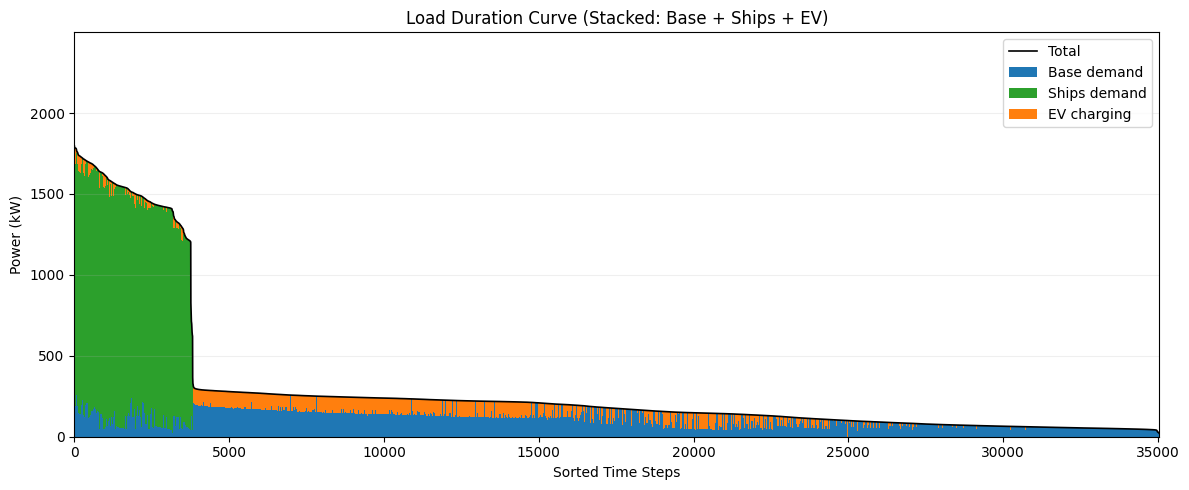

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
file_path = "outputs/ferryterminal_loadshifting.xlsx"
sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL],   errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[SHIP_COL] + tmp[EV_COL]

# Sort descending by total load (duration curve)
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# x = sorted time-step index
x = np.arange(len(tmp))

base_sorted  = tmp[BASE_COL].values
ship_sorted  = tmp[SHIP_COL].values
ev_sorted    = tmp[EV_COL].values
base_ship_top = base_sorted + ship_sorted
total_sorted = tmp["total"].values

# ----------------------------
# Plot (stacked, striped style)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Layer 1: base
ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)

# Layer 2: ships (on top of base)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)

# Layer 3: EV (on top of base+ships)
ax.bar(x, ev_sorted, width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)

# Top envelope line
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve (Stacked: Base + Ships + EV)")
ax.set_xlabel("Sorted Time Steps")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(0, 2499)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

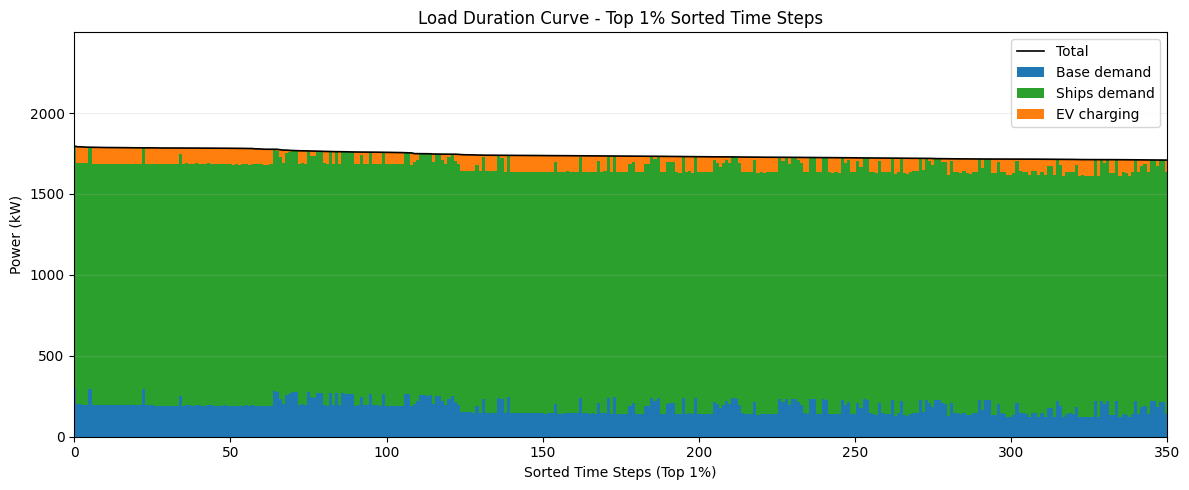

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------
file_path = "outputs/ferryterminal_loadshifting.xlsx"
sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["base_ship"] = tmp[BASE_COL] + tmp[SHIP_COL]
tmp["total"] = tmp["base_ship"] + tmp[EV_COL]

# Sort by total, then break ties by base+ships
tmp = tmp.sort_values(
    ["total", "base_ship", EV_COL],
    ascending=[False, False, True]
).reset_index(drop=True)

# Keep only top 1% sorted timesteps
n = len(tmp)
top_n = max(1, int(np.ceil(0.01 * n)))
top = tmp.iloc[:top_n].copy()

x = np.arange(top_n)
base_sorted = top[BASE_COL].values
ship_sorted = top[SHIP_COL].values
ev_sorted   = top[EV_COL].values
base_ship_top = top["base_ship"].values
total_sorted = top["total"].values

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)
ax.bar(x, ev_sorted,   width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve - Top 1% Sorted Time Steps")
ax.set_xlabel("Sorted Time Steps (Top 1%)")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, top_n - 1)
ax.set_ylim(0, 2499)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

Selected week: 2025-10-13/2025-10-19 (price range = 5.494 EUR/kWh)


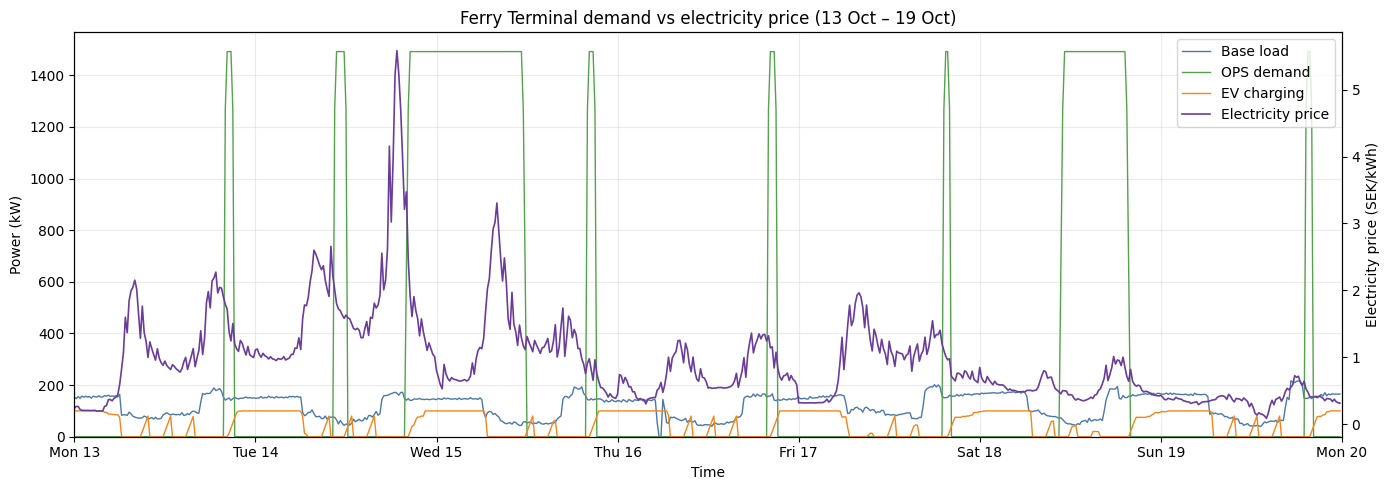

In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
OPS_COL = "shore_power_demand_kw"
EV_COL = "EV_charging_kw"
PRICE_COL = "da_price"

# Load demand components
if "out_df" in globals():
    df = out_df[[TIME_COL, BASE_COL, OPS_COL, EV_COL]]
else:
    df = pd.read_excel(file_path)[[TIME_COL, BASE_COL, OPS_COL, EV_COL]]

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
for col in [BASE_COL, OPS_COL, EV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

# Load electricity price
price = da_price[[TIME_COL, PRICE_COL]].copy()
price[TIME_COL] = pd.to_datetime(price[TIME_COL], errors="coerce")
price[PRICE_COL] = pd.to_numeric(price[PRICE_COL], errors="coerce")

plot_df = df.merge(price, on=TIME_COL, how="inner").sort_values(TIME_COL)

# Pick week with largest price fluctuation
plot_df["week"] = plot_df[TIME_COL].dt.to_period("W-SUN")
week_stats = plot_df.groupby("week")[PRICE_COL].agg(lambda s: s.max() - s.min())
selected_week = week_stats.idxmax()
print(f"Selected week: {selected_week} (price range = {week_stats.max():.3f} EUR/kWh)")

week_df = plot_df[plot_df["week"] == selected_week].copy()
start = week_df[TIME_COL].min()
end = week_df[TIME_COL].max() + pd.Timedelta(minutes=15)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(week_df[TIME_COL], week_df[BASE_COL], color="#4C78A8", linewidth=1.0, label="Base load")
ax1.plot(week_df[TIME_COL], week_df[OPS_COL], color="#54A24B", linewidth=1.0, label="OPS demand")
ax1.plot(week_df[TIME_COL], week_df[EV_COL], color="#F58518", linewidth=1.0, label="EV charging")

ax1.set_ylabel("Power (kW)")
power_max = week_df[[BASE_COL, OPS_COL, EV_COL]].max().max()
ax1.set_ylim(0, max(1000, power_max * 1.05))
ax1.set_xlabel("Time")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(week_df[TIME_COL], week_df[PRICE_COL], color="#6A3D9A", linewidth=1.2, label="Electricity price")
ax2.set_ylabel("Electricity price (SEK/kWh)")

ax1.set_title(f"Ferry Terminal demand vs electricity price ({start:%d %b} – {end - pd.Timedelta(days=1):%d %b})")
ax1.set_xlim(start, end)
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

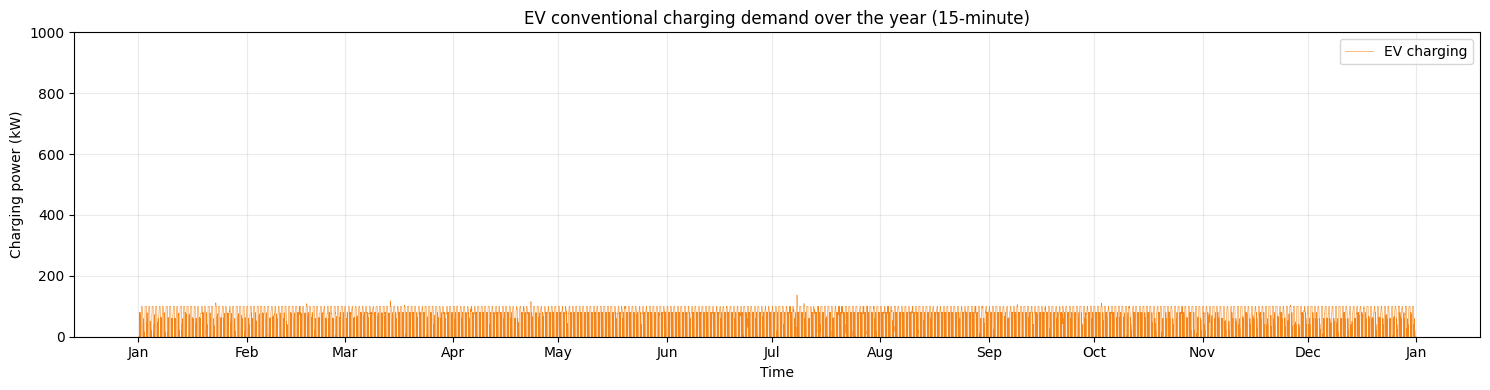

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

TIME_COL = "datetime"
EV_COL = "EV_charging_kw"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)
df[EV_COL] = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Full year (15-min)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df[TIME_COL], df[EV_COL], linewidth=0.4, color="#F58518", label="EV charging")
ax.set_ylabel("Charging power (kW)")
ax.set_xlabel("Time")
ax.set_title("EV conventional charging demand over the year (15-minute)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.25)
ax.set_ylim(0, 1000)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()